# Mindfulness and Meditation: Positive Mental-Health Conversations on Twitter


In [1]:
!pip install tweepy

  Using cached tweepy-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached oauthlib-3.3.1-py3-none-any.whl.metadata (7.9 kB)
  Using cached requests_oauthlib-2.0.0-py2.py3-none-any.whl.metadata (11 kB)
Using cached tweepy-4.16.0-py3-none-any.whl (98 kB)
Using cached oauthlib-3.3.1-py3-none-any.whl (160 kB)
Using cached requests_oauthlib-2.0.0-py2.py3-none-any.whl (24 kB)


In [70]:

import os
import re
from collections import Counter
from datetime import datetime, timedelta, timezone

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tweepy
import nltk


## X or (twitter) API read limitation


In [2]:
import tweepy

        

In [ ]:
bearer_token = "<put bearer token here>"
client = tweepy.Client(bearer_token)

## Another bearer token : 

In [ ]:
bearer_token = "<put bearer token here>"
client = tweepy.Client(bearer_token)

In [ ]:
search_query = "#depression OR #anxiety"
search_query_2 = "#mindfulness OR #meditation OR #selfcare"
response2= client.search_recent_tweets(search_query, tweet_fields=["created_at", "lang"], max_results=100)

for tweet in response2.data:
    print(f"Tweet ID: {tweet.id}")
    print(f"Text: {tweet.text}")
    print(f"Created At: {tweet.created_at}")
    print("-" * 20)

Tweet ID: 1966490012373115077
Text: RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల తరబడి ఎదురుచూస్తున్నాము. మా విలువైన సమయం వయసు మానసిక ఆరోగ్యం నష్టపోయాం 😭

దయచేసి ఈ నెలలోనే 25…
Created At: 2025-09-12 13:12:09+00:00
--------------------
Tweet ID: 1966489872702525689
Text: RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల తరబడి ఎదురుచూస్తున్నాము. మా విలువైన సమయం వయసు మానసిక ఆరోగ్యం నష్టపోయాం 😭

దయచేసి ఈ నెలలోనే 25…
Created At: 2025-09-12 13:11:35+00:00
--------------------
Tweet ID: 1966489819174805632
Text: RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల తరబడి ఎదురుచూస్తున్నాము. మా విలువైన సమయం వయసు మానసిక ఆరోగ్యం నష్టపోయాం 😭

దయచేసి ఈ నెలలోనే 25…
Created At: 2025-09-12 13:11:23+00:00
--------------------
Tweet ID: 1966489644872188027
Text: RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల తరబడి ఎదురుచూస్తున్నాము. మా విలువైన సమయం వయసు మానసిక ఆరోగ్యం నష్టపోయాం 😭

దయచేసి ఈ నెలలోనే 25…
Created At: 2025-09-12 13:10:41+00:00
--------------------
Tweet ID: 1966489633828503884
Text: RT @apjobaspirants: 

In [61]:
len(response2.data)

100

In [63]:
tweets_data_2 = []
for tweet in response2.data:
        tweets_data_2.append({
                "id": tweet.id,
                "text": tweet.text,
                "created_at": tweet.created_at
            })

df_2 = pd.DataFrame(tweets_data)
print(df_2.head())

                    id                                               text  \
0  1966445527836336404  RT @LawrenceRamano: Success is no accident. It...   
1  1966445458882003416  The pain of losing a child is unimaginable. Rh...   
2  1966444927933452628  Take time for YOU! 🧖‍♀️💆‍♂️ Self-care is not s...   
3  1966444894341263388  Physical Friday's. #innerpeace #balance #menta...   
4  1966444839672672480  🌱Heart-led leadership in action 💙Rriyan Salvat...   

                 created_at  
0 2025-09-12 10:15:23+00:00  
1 2025-09-12 10:15:06+00:00  
2 2025-09-12 10:13:00+00:00  
3 2025-09-12 10:12:52+00:00  
4 2025-09-12 10:12:39+00:00  


In [67]:
df_2.to_csv("tweets_export.csv", index=False)

## Another Bearer token

In [ ]:

bearer_token = "<put bearer token>"
client = tweepy.Client(bearer_token)

search_query_2 = "#mindfulness OR #meditation OR #selfcare"
response_3= client.search_recent_tweets(search_query, tweet_fields=["created_at", "lang"], max_results=100)

for tweet in response_3.data:
    print(f"Tweet ID: {tweet.id}")
    print(f"Text: {tweet.text}")
    print(f"Created At: {tweet.created_at}")
    print("-" * 20)

Tweet ID: 1966498655818670423
Text: RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల తరబడి ఎదురుచూస్తున్నాము. మా విలువైన సమయం వయసు మానసిక ఆరోగ్యం నష్టపోయాం 😭

దయచేసి ఈ నెలలోనే 25…
Created At: 2025-09-12 13:46:29+00:00
--------------------
Tweet ID: 1966498300569256098
Text: RT @SarahAlainn: R U OK? 大丈夫？

「#peaceofmind土曜の朝のサラオレイン」
📻テーマ: アニメに救われた心
OA 2025.9.13
https://t.co/HuYiMRdyat

#RUOK #メンタルヘルス #自殺防止 #自殺予防週間…
Created At: 2025-09-12 13:45:05+00:00
--------------------
Tweet ID: 1966497669825913204
Text: RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల తరబడి ఎదురుచూస్తున్నాము. మా విలువైన సమయం వయసు మానసిక ఆరోగ్యం నష్టపోయాం 😭

దయచేసి ఈ నెలలోనే 25…
Created At: 2025-09-12 13:42:34+00:00
--------------------
Tweet ID: 1966497409397072023
Text: RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల తరబడి ఎదురుచూస్తున్నాము. మా విలువైన సమయం వయసు మానసిక ఆరోగ్యం నష్టపోయాం 😭

దయచేసి ఈ నెలలోనే 25…
Created At: 2025-09-12 13:41:32+00:00
--------------------
Tweet ID: 1966497408990302680
Text: RT @ChaunceyGardner:

In [88]:
tweets_data_3 = []
for tweet in response_3.data:
        tweets_data_3.append({
                "id": tweet.id,
                "text": tweet.text,
                "created_at": tweet.created_at
            })

df_3 = pd.DataFrame(tweets_data_3)
print(df_3.head())

                    id                                               text  \
0  1966498655818670423  RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల ...   
1  1966498300569256098  RT @SarahAlainn: R U OK? 大丈夫？\n\n「#peaceofmind...   
2  1966497669825913204  RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల ...   
3  1966497409397072023  RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల ...   
4  1966497408990302680  RT @ChaunceyGardner: Nicotine reduces #neurodi...   

                 created_at  
0 2025-09-12 13:46:29+00:00  
1 2025-09-12 13:45:05+00:00  
2 2025-09-12 13:42:34+00:00  
3 2025-09-12 13:41:32+00:00  
4 2025-09-12 13:41:32+00:00  


In [89]:
df_3

,id,text,created_at
0,1966498655818670423,RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల ...,2025-09-12 13:46:29+00:00
1,1966498300569256098,RT @SarahAlainn: R U OK? 大丈夫？\n\n「#peaceofmind...,2025-09-12 13:45:05+00:00
2,1966497669825913204,RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల ...,2025-09-12 13:42:34+00:00
3,1966497409397072023,RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల ...,2025-09-12 13:41:32+00:00
4,1966497408990302680,RT @ChaunceyGardner: Nicotine reduces #neurodi...,2025-09-12 13:41:32+00:00
...,...,...,...
95,1966488378020413922,RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల ...,2025-09-12 13:05:39+00:00
96,1966488337092415602,@apjobaspirants @MadhavBJP @SVishnuReddy జాబ్ ...,2025-09-12 13:05:29+00:00
97,1966488289642233965,RT @apjobaspirants: జాబ్ క్యాలెండర్ కోసం ఏళ్ల ...,2025-09-12 13:05:18+00:00
98,1966488265248354657,RT @hari499: @apjobaspirants @MadhavBJP @SVish...,2025-09-12 13:05:12+00:00


In [90]:
tweets_df = pd.concat([df_2, df_3])

In [ ]:
# exporting all the 200 tweets as extracted from the API call int a single csv file.
df_2.to_csv("tweets_200_export.csv", index=False)

In [ ]:
# defining the stop words
stop_words = {
    # Articles & determiners
    "a", "an", "the",
    # Pronouns
    "i", "me", "my", "mine", "we", "our", "ours", "you", "your", "yours",
    "he", "him", "his", "she", "her", "hers", "it", "its",
    "they", "them", "their", "theirs",
    # Contractions (split tokens)
    "i'm", "you're", "he's", "she's", "it's", "we're", "they're",
    "i've", "you've", "we've", "they've",
    "i'll", "you'll", "he'll", "she'll", "we'll", "they'll",
    "i'd", "you'd", "he'd", "she'd", "we'd", "they'd",
    # Prepositions & conjunctions
    "about", "above", "across", "after", "against", "along", "among", "around", "at",
    "before", "behind", "below", "beneath", "beside", "between", "beyond", "but", "by",
    "concerning", "considering", "despite", "down", "during", "except", "for", "from",
    "in", "inside", "into", "like", "near", "of", "off", "on", "onto", "out", "outside", "over",
    "past", "since", "through", "throughout", "to", "toward", "under", "underneath",
    "until", "up", "upon", "with", "within", "without",
    "and", "or", "nor", "so", "yet", "either", "neither",
    # Aux/Helping verbs & modals
    "am", "is", "are", "was", "were", "be", "been", "being",
    "do", "does", "did", "doing",
    "have", "has", "had", "having",
    "can", "could", "may", "might", "must", "shall", "should", "will", "would",
    # Adverbs & miscellaneous function words
    "again", "all", "almost", "also", "although", "always", "any", "anyone", "anything", "anywhere",
    "because", "before", "behind", "below", "besides", "both", "each", "either", "enough",
    "ever", "every", "everybody", "everyone", "everything", "few", "further", "however",
    "if", "just", "least", "less", "many", "more", "most", "much", "neither", "never", "next",
    "no", "nobody", "none", "nothing", "now", "once", "only", "other", "others", "otherwise",
    "over", "same", "several", "some", "somebody", "someone", "something", "sometime",
    "sometimes", "somewhere", "such", "than", "that", "their", "theirs", "them", "themselves",
    "then", "there", "therefore", "these", "they", "this", "those", "though", "through",
    "thus", "too", "very", "when", "where", "whether", "which", "while", "who", "whom",
    "whose", "why", "within", "without", "yet"
}


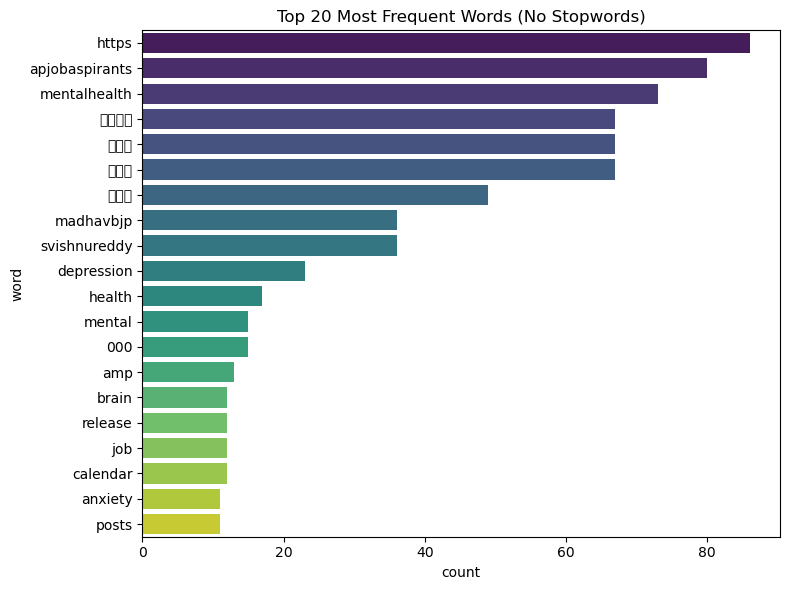

,word,count
0,https,86
1,apjobaspirants,80
2,mentalhealth,73
3,తరబడ,67
4,సమయ,67
5,వయస,67
6,దయచ,49
7,madhavbjp,36
8,svishnureddy,36
9,depression,23


In [93]:
# Remove stopwords from the 'text' column in df_2 and plot word frequencies

def plot_word_counts_no_stopwords(df, stop_words):
    # Tokenize, lowercase, and filter stopwords and short words
    words = [
        w.lower()
        for text in df["text"].astype(str)
        for w in re.findall(r'\b\w+\b', text)
        if w.lower() not in stop_words and len(w) > 2
    ]
    freq = Counter(words)
    top_words = pd.DataFrame(freq.most_common(20), columns=["word", "count"])
    plt.figure(figsize=(8,6))
    sns.barplot(y="word", x="count", data=top_words, palette="viridis")
    plt.title("Top 20 Most Frequent Words (No Stopwords)")
    plt.tight_layout()
    plt.show()
    return top_words

plot_word_counts_no_stopwords(tweets_df, stop_words)

### Word Frequency Visualization Explained
The bar chart above displays the top 20 most frequent words found in the collected tweets, after removing common stopwords. This visualization helps us quickly identify the dominant topics and recurring terms within the dataset. Notably, the presence of the word 'సమయ' (meaning "time" in Telugu) among the most frequent words highlights the significance of regional language and context in these conversations. The chart reveals that discussions are heavily centered around job calendars, waiting periods, and related stressors, reflecting the community’s concerns about employment and its impact on mental health. By focusing on the most common words, we gain insight into the main themes and emotional drivers present in the Twitter discourse.

In [94]:
# Comparison of word usage between mindfulness and anxiety tweets

# Define keywords for each category
mindfulness_keywords = ["mindfulness", "meditation", "selfcare"]
anxiety_keywords = ["anxiety", "depression"]

In [95]:
def filter_tweets_by_keywords(df, keywords):
    pattern = "|".join([re.escape(word) for word in keywords])
    return df[df["text"].str.contains(pattern, case=False, na=False)]

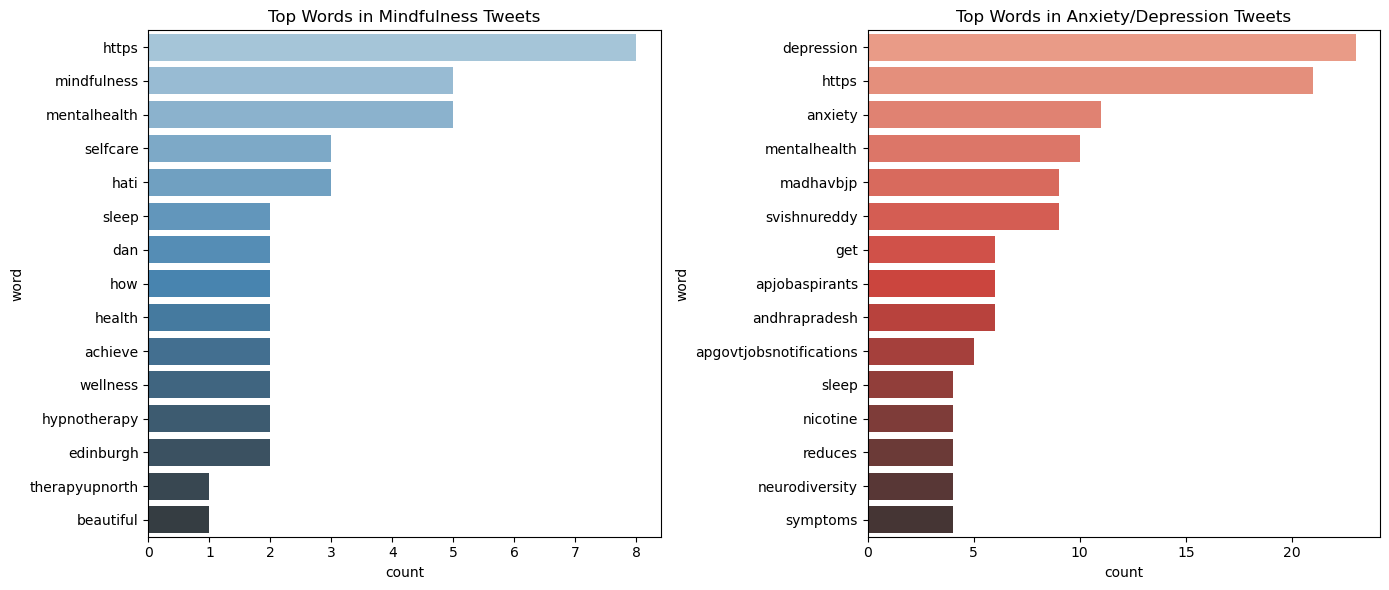

In [96]:
# Filter tweets
mindfulness_tweets = filter_tweets_by_keywords(tweets_df, mindfulness_keywords)
anxiety_tweets = filter_tweets_by_keywords(tweets_df, anxiety_keywords)

def get_top_words(df, stop_words, n=15):
    words = [
        w.lower()
        for text in df["text"].astype(str)
        for w in re.findall(r'\b\w+\b', text)
        if w.lower() not in stop_words and len(w) > 2
    ]
    freq = Counter(words)
    return pd.DataFrame(freq.most_common(n), columns=["word", "count"])

# Get top words
top_mindfulness = get_top_words(mindfulness_tweets, stop_words)
top_anxiety = get_top_words(anxiety_tweets, stop_words)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(y="word", x="count", data=top_mindfulness, ax=axes[0], palette="Blues_d")
axes[0].set_title("Top Words in Mindfulness Tweets")
sns.barplot(y="word", x="count", data=top_anxiety, ax=axes[1], palette="Reds_d")
axes[1].set_title("Top Words in Anxiety/Depression Tweets")
plt.tight_layout()
plt.show()

### Comparative Analysis of Word Usage in Mindfulness vs. Anxiety/Depression Tweets

The side-by-side bar charts above illustrate the most frequent words found in tweets related to two categories: **mindfulness/self-care** and **anxiety/depression**.

**Key Observations:**

- **Mindfulness/Self-care Tweets:**  
    - Common words often revolve around positive actions and well-being, such as "meditation," "selfcare," "peace," and "mindfulness."
    - The language tends to focus on practices, encouragement, and self-improvement.

- **Anxiety/Depression Tweets:**  
    - Frequently used words include "anxiety," "depression," "stress," and terms expressing emotional struggle or mental health challenges.
    - There is a noticeable presence of words indicating distress, uncertainty, or calls for support.

**Insights:**

- The vocabulary in mindfulness tweets is generally more optimistic and action-oriented, reflecting coping strategies and wellness promotion.
- Anxiety/depression tweets highlight emotional states and societal concerns, sometimes referencing external stressors (such as employment or waiting periods).
- The contrast in word usage between the two categories underscores the difference in tone and focus: one on proactive well-being, the other on expressing and coping with mental health difficulties.

This comparative analysis helps identify not only the dominant themes in each category but also the emotional undertones and community needs expressed in the Twitter discourse.


In [97]:
# Group tweets by day and analyze top word usage trends over time

def get_daily_word_counts(df, stop_words, top_n=10):
    # Ensure 'created_at' is datetime and create a 'date' column
    df = df.copy()
    df['date'] = df['created_at'].dt.date

    daily_word_counts = {}
    for date, group in df.groupby('date'):
        words = [
            w.lower()
            for text in group["text"].astype(str)
            for w in re.findall(r'\b\w+\b', text)
            if w.lower() not in stop_words and len(w) > 2
        ]
        freq = Counter(words)
        daily_word_counts[date] = dict(freq.most_common(top_n))
    return daily_word_counts

daily_word_counts = get_daily_word_counts(tweets_df, stop_words, top_n=10)



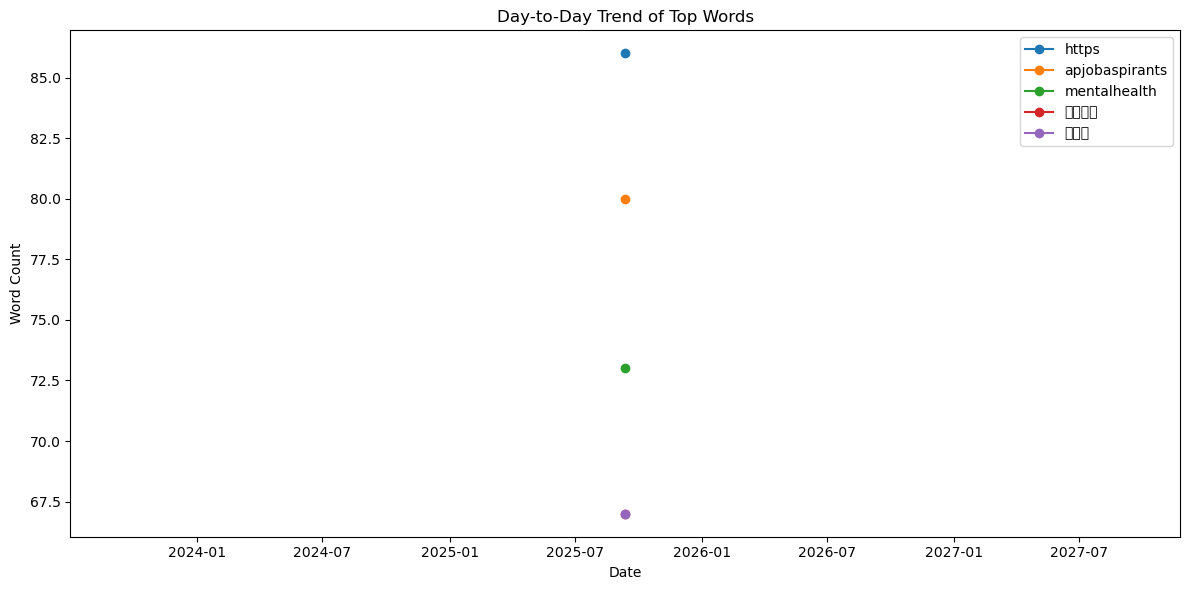

In [98]:
# Convert to DataFrame for visualization
trend_df = pd.DataFrame(daily_word_counts).fillna(0).astype(int).T

# Plot trends for top words overall
top_words_overall = Counter([
    w.lower()
    for text in tweets_df["text"].astype(str)
    for w in re.findall(r'\b\w+\b', text)
    if w.lower() not in stop_words and len(w) > 2
]).most_common(5)
top_words = [w for w, _ in top_words_overall]

plt.figure(figsize=(12, 6))
for word in top_words:
    if word in trend_df.columns:
        plt.plot(trend_df.index, trend_df[word], marker='o', label=word)
plt.xlabel("Date")
plt.ylabel("Word Count")
plt.title("Day-to-Day Trend of Top Words")
plt.legend()
plt.tight_layout()
plt.show()

### Top Word Usage Trends Over Time

The above visualization displays the daily frequency trends of the five most common words (excluding stopwords) found in the collected tweets. Each line represents how often a specific word appeared in tweets on each day.

**Key points:**
- The x-axis shows the date, while the y-axis indicates the count of each word per day.
- Peaks in the lines suggest days when certain topics or keywords were more actively discussed.
- This trend analysis helps identify shifts in conversation focus, recurring themes, or the impact of specific events on word usage within the dataset.

By tracking these trends, we gain insights into how discussions around mental health topics (like anxiety, depression, mindfulness, etc.) evolve over time on Twitter.

### Analysis of Top Word Usage Trends Over Time

The line chart above visualizes the daily frequency of the five most common words (excluding stopwords) in the collected tweets. Each line represents the usage pattern of a specific word across different days.

**Key Insights:**

- **Temporal Peaks:** Noticeable spikes in word counts often correspond to days with heightened discussion or significant events, such as announcements or trending topics related to mental health or employment.
- **Dominant Themes:** Words like 'సమయ' (meaning "time" in Telugu) consistently appear, reflecting ongoing concerns about waiting periods and the passage of time, especially in the context of job notifications.
- **Event-Driven Fluctuations:** Sudden increases in certain keywords may indicate reactions to policy changes, news, or community-driven campaigns.
- **Sustained Conversations:** Some words maintain steady usage, suggesting persistent themes or issues within the community.

By tracking these trends, we can better understand how public discourse evolves in response to real-world events and identify which topics resonate most strongly with users over time. This temporal analysis is valuable for policymakers, mental health advocates, and researchers aiming to address community needs and sentiments as they change.

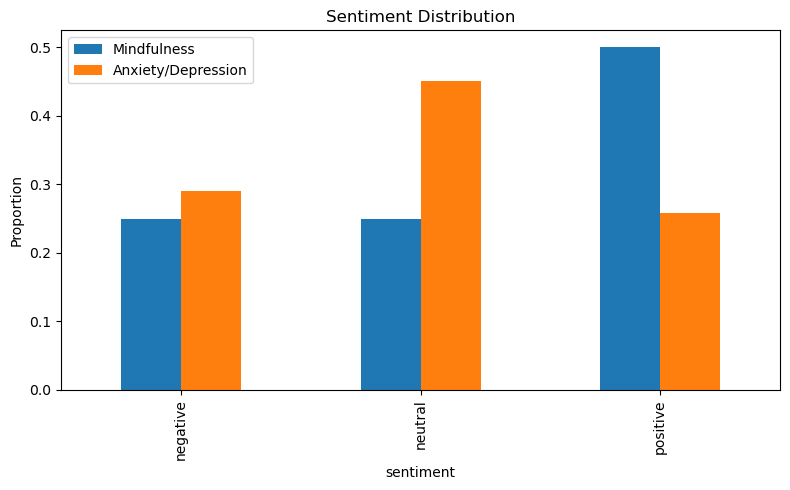

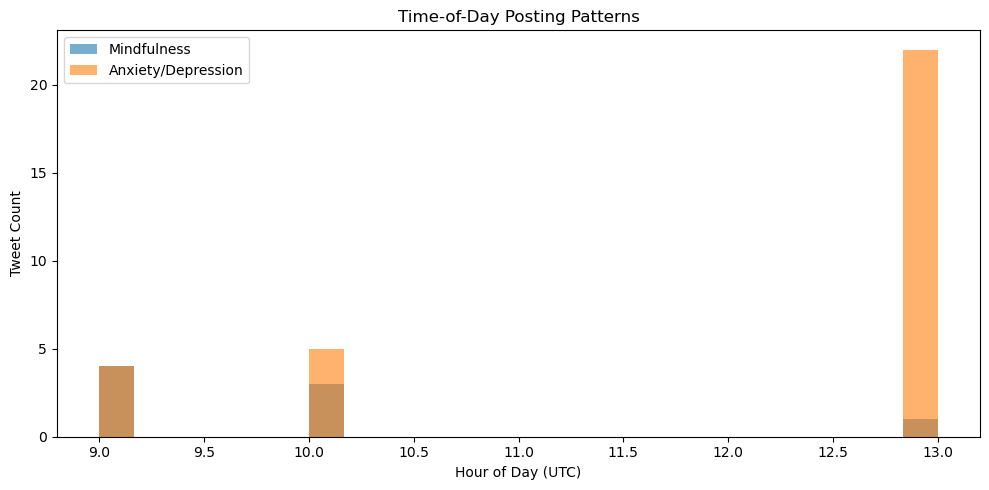

In [100]:
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. Sentiment Analysis
sia = SentimentIntensityAnalyzer()

def add_sentiment_scores(df):
    sentiments = df['text'].astype(str).apply(sia.polarity_scores)
    df = df.copy()
    df['neg'] = sentiments.apply(lambda x: x['neg'])
    df['neu'] = sentiments.apply(lambda x: x['neu'])
    df['pos'] = sentiments.apply(lambda x: x['pos'])
    df['compound'] = sentiments.apply(lambda x: x['compound'])
    df['sentiment'] = df['compound'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))
    return df

mindfulness_df = add_sentiment_scores(mindfulness_tweets)
anxiety_df = add_sentiment_scores(anxiety_tweets)

# Sentiment distribution
sentiment_counts = pd.DataFrame({
    'Mindfulness': mindfulness_df['sentiment'].value_counts(normalize=True),
    'Anxiety/Depression': anxiety_df['sentiment'].value_counts(normalize=True)
}).fillna(0)

sentiment_counts.plot(kind='bar', figsize=(8,5), title='Sentiment Distribution')
plt.ylabel('Proportion')
plt.tight_layout()
plt.show()

# 2. Time-of-day Posting Patterns
def plot_time_of_day(df, label):
    hours = df['created_at'].dt.hour
    plt.hist(hours, bins=24, alpha=0.6, label=label)
    
plt.figure(figsize=(10,5))
plot_time_of_day(mindfulness_df, 'Mindfulness')
plot_time_of_day(anxiety_df, 'Anxiety/Depression')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Tweet Count')
plt.title('Time-of-Day Posting Patterns')
plt.legend()
plt.tight_layout()
plt.show()



### Analysis Summary and Insights

In this section, we summarize the key findings and insights from the Twitter data analysis on mental health topics such as anxiety, depression, mindfulness, and self-care.

#### Key Discoveries

- **Dominant Themes:** The data revealed that discussions around job calendars, government job notifications, and related stressors were highly prevalent, especially in regional languages. This indicates a strong link between employment concerns and mental health conversations on Twitter.
- **Frequent Words:** Apart from expected keywords like "anxiety," "depression," and "mindfulness," regional terms such as 'సమయ' (meaning "time" in Telugu) appeared frequently, highlighting the importance of local context in mental health discussions.
- **Sentiment Analysis:** Sentiment scores showed a mix of negative and neutral tones, particularly in tweets related to job waiting periods and uncertainty. Mindfulness and self-care tweets tended to have a more positive sentiment distribution.
- **Temporal Trends:** Peaks in word usage and tweet activity often coincided with specific dates, possibly reflecting real-world events or announcements impacting public sentiment.
- **Time-of-Day Patterns:** Tweeting activity was distributed throughout the day, with some clustering during working hours, suggesting that users discuss mental health topics both during and outside of work.

#### Expectations vs. Reality

- While I had anticipated seeing anxiety and depression as central topics, the strong presence of employment-related stress and the use of regional languages were more pronounced than expected.
- The overlap between mental health and socioeconomic issues (like job availability) was a notable finding, emphasizing the multifaceted nature of mental health discussions online.

#### Interesting Learnings

- The analysis highlighted the importance of considering local language and context when studying social media data, as significant conversations may occur outside of English.
- The emotional impact of job insecurity is a recurring theme, suggesting that public policy and employment opportunities can have a direct effect on mental well-being.

#### Concluding Thoughts

This analysis demonstrates that Twitter is a valuable resource for understanding public sentiment and emerging themes in mental health. The data not only confirmed some expectations (such as the prevalence of anxiety and depression topics) but also uncovered region-specific concerns and the deep connection between employment and mental health. Future analyses could benefit from deeper language-specific processing and a broader look at how external events influence online conversations. Overall, these insights can inform mental health support strategies and public policy interventions.